In [1]:
import pandas as pd
import numpy as np 
import math

import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision.models as models
from torch.utils.data import DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import json
import time
from tqdm import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [2]:
df = pd.read_parquet("Data/dipser_dataset.parquet", engine="pyarrow")

In [3]:
df["time_sec"] = (pd.to_datetime(df["time"]))

# convert it to 0-300
df["time_sec"] = (
    df.groupby("subject_experiment_id")["time_sec"]
    .transform(lambda x:
        (x - x.min())
        .dt.total_seconds()
        .astype(int)
    )
)
df.head()

,group,time,image_path,metadata,subject,experiment,self_labeling emotion,self_labeling attention,labeler_02 attention,labeler_04 attention,labeler_02 emotion,labeler_01 attention,labeler_03 emotion,labeler_03 attention,labeler_01 emotion,labeler_04 emotion,self_labeling emotionfilled,self_labeling attentionfilled,labeler_02 attentionfilled,labeler_04 attentionfilled,labeler_02 emotionfilled,labeler_01 attentionfilled,labeler_03 emotionfilled,labeler_03 attentionfilled,labeler_01 emotionfilled,labeler_04 emotionfilled,samsung_rotation_vector value0_mean,samsung_rotation_vector value0_std,samsung_rotation_vector value1_mean,samsung_rotation_vector value1_std,samsung_rotation_vector value2_mean,samsung_rotation_vector value2_std,samsung_rotation_vector value3_mean,samsung_rotation_vector value3_std,samsung_rotation_vector value4_mean,samsung_rotation_vector value4_std,lsm6dso_gyroscope value0_mean,lsm6dso_gyroscope value0_std,lsm6dso_gyroscope value1_mean,lsm6dso_gyroscope value1_std,lsm6dso_gyroscope value2_mean,lsm6dso_gyroscope value2_std,samsung_linear_acceleration_sensor value0_mean,samsung_linear_acceleration_sensor value0_std,samsung_linear_acceleration_sensor value1_mean,samsung_linear_acceleration_sensor value1_std,samsung_linear_acceleration_sensor value2_mean,samsung_linear_acceleration_sensor value2_std,opt3007_light value0_mean,opt3007_light value0_std,heart_rate,heart_rate_std,accel_magnitude_mean,accel_magnitude_std,gyro_magnitude_mean,gyro_magnitude_std,labeler_05 emotion,labeler_05 attention,labeler_05 emotionfilled,labeler_05 attentionfilled,invalid_reason,gender,age,race,subject_experiment_id,attention,subject_id,time_sec
0,group01,2026-05-08 10:40:43.047895,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_047895.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_047895.json,subject_01,experiment01,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109524,0.000163,-0.659717,0.000588,0.632875,0.000495,0.390186,0.000218,246.0,0.0,-0.006022,0.006482,-0.003838,0.003665,-0.000864,0.006845,0.052984,0.034713,-0.132399,0.047077,0.017549,0.043508,63.0,0.0,78.0,NaN,0.155556,0.041540,0.011095,0.005498,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,0
1,group01,2026-05-08 10:40:43.195317,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_195317.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_195317.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109485,0.000109,-0.660015,0.000520,0.632620,0.000426,0.390106,0.000225,246.0,0.0,-0.004508,0.005235,-0.004068,0.003267,-0.001026,0.005944,0.053056,0.036979,-0.124020,0.045047,0.012282,0.043478,63.0,0.0,78.0,NaN,0.148634,0.038779,0.009572,0.004378,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,0
2,group01,2026-05-08 10:40:43.295405,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_295405.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_295405.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109478,0.000101,-0.660194,0.000514,0.632473,0.000406,0.390043,0.000252,246.0,0.0,-0.004581,0.005193,-0.003897,0.003153,-0.000525,0.005644,0.054420,0.036670,-0.129478,0.044805,0.015730,0.040968,63.0,0.0,78.0,NaN,0.153129,0.038995,0.009384,0.004079,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,0
3,group01,2026-05-08 10:40:43.395835,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_395835.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_395835.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [4]:
df[['attention', 'heart_rate', 'gender', 'age']].isna().sum()

attention     0
heart_rate    0
gender        0
age           0
dtype: int64

In [5]:
sensor_cols = [
    col for col in df.columns
    if (
        (
            "sensor" in col.lower()
            or "acceleration" in col.lower()
            or "gyro" in col.lower()
            or "rotation" in col.lower()
            or "heart" in col.lower()
            or "light" in col.lower()
            or "accel" in col.lower()
        )
        and "std" not in col.lower()
    )
]

In [6]:
sensor_cols

['samsung_rotation_vector value0_mean',
 'samsung_rotation_vector value1_mean',
 'samsung_rotation_vector value2_mean',
 'samsung_rotation_vector value3_mean',
 'samsung_rotation_vector value4_mean',
 'lsm6dso_gyroscope value0_mean',
 'lsm6dso_gyroscope value1_mean',
 'lsm6dso_gyroscope value2_mean',
 'samsung_linear_acceleration_sensor value0_mean',
 'samsung_linear_acceleration_sensor value1_mean',
 'samsung_linear_acceleration_sensor value2_mean',
 'opt3007_light value0_mean',
 'heart_rate',
 'accel_magnitude_mean',
 'gyro_magnitude_mean']

In [7]:
# fill with mean the remaining nan values
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].mean())
df[sensor_cols] = df[sensor_cols].astype(np.float32)

In [8]:
metadata_cols = ["experiment", "group", 'subject_id', "gender", "age"]

# aggregate sensor features
df_sensor = df.groupby(["subject_experiment_id", "time_sec"])[sensor_cols].mean().reset_index()

# aggregate attention target
df_attention = df.groupby(["subject_experiment_id", "time_sec"])["attention"].mean().reset_index()

# merge sensors + target
df_sensor = df_sensor.merge(df_attention, on=["subject_experiment_id", "time_sec"])

# keep metadata
df_meta = df.groupby(["subject_experiment_id", "time_sec"])[metadata_cols].first().reset_index()

df_sensors_metadata = df_meta.merge(df_sensor, on=["subject_experiment_id", "time_sec"])

# # keep only 1 frame per second (the first)
# df_sec = (df.sort_values("time")
#       .groupby(["subject_experiment_id", "time_sec"])
#       .first()
#       .reset_index())

In [9]:
class TemporalSensorDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx], idx

### Train Test Split

In [11]:
subject_df = df_sensors_metadata[['subject_id', 'gender']].drop_duplicates()

train_sub, temp_sub = train_test_split(
    subject_df,
    test_size=0.3,
    stratify=subject_df['gender'],
    random_state=42)

# further break temp for balanced val and test
val_sub, test_sub = train_test_split(
    temp_sub,
    test_size=0.5,
    stratify=temp_sub['gender'],
    random_state=42)

train_subjects = train_sub['subject_id']
val_subjects = val_sub['subject_id']
test_subjects = test_sub['subject_id']

train_df = df_sensors_metadata[df_sensors_metadata["subject_id"].isin(train_subjects)]
val_df  = df_sensors_metadata[df_sensors_metadata["subject_id"].isin(val_subjects)]
test_df  = df_sensors_metadata[df_sensors_metadata["subject_id"].isin(test_subjects)]

### Normalize Sensor Features

In [12]:
scaler = StandardScaler()

train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
val_df[sensor_cols] = scaler.transform(val_df[sensor_cols])
test_df[sensor_cols]  = scaler.transform(test_df[sensor_cols])

/scratch-local/cfragkiadakis.22708697/ipykernel_208185/1846154732.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
/scratch-local/cfragkiadakis.22708697/ipykernel_208185/1846154732.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[sensor_cols] = scaler.transform(val_df[sensor_cols])
/scratch-local/cfragkiadakis.22708697/ipykernel_208185/1846154732.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

In [13]:
# SEQ_LEN = 15

# def create_sequences(df, sensor_cols, seq_len=10):

#     X_sequences = []
#     y_sequences = []

#     for seq_id, seq_df in df.groupby("subject_experiment_id"):

#         seq_df = seq_df.sort_values("time_sec").reset_index(drop=True)

#         # convert to seconds
#         times = seq_df["time_sec"].astype("int64") // 1_000_000_000

#         X = seq_df[sensor_cols].values
#         y = seq_df["attention"].values

#         if len(seq_df) < seq_len:
#             continue

#         for i in range(seq_len - 1, len(seq_df)):

#             start_idx = i - seq_len + 1

#             time_window = times.iloc[start_idx:i+1].values

#             # check consecutive seconds
#             diffs = np.diff(time_window)

#             if not np.all(diffs == 1):
#                 continue

#             x_seq = X[start_idx:i+1]
#             y_target = y[i]

#             # skip NaNs
#             if np.isnan(x_seq).any():
#                 continue

#             if np.isnan(y_target):
#                 continue

#             X_sequences.append(x_seq)
#             y_sequences.append(y_target)

#     return np.array(X_sequences), np.array(y_sequences)

In [22]:
SEQ_LEN = 10

def create_sequences(df, sensor_cols, seq_len=10):

    X_sequences = []
    y_sequences = []

    for seq_id, seq_df in df.groupby("subject_experiment_id"):

        seq_df = seq_df.sort_values("time_sec")

        # full second timeline
        full_range = np.arange(
            seq_df["time_sec"].min(),
            seq_df["time_sec"].max() + 1
        )

        # reindex
        seq_df = (
            seq_df
            .set_index("time_sec")
            .reindex(full_range)
        )

        seq_df.index.name = "time_sec"

        # keep identifier
        seq_df["subject_experiment_id"] = seq_id

        # target
        y = seq_df["attention"].values

        # sensors
        X = seq_df[sensor_cols].values

        # replace missing timesteps with zeros
        X = np.nan_to_num(X, nan=0.0)

        # optional:
        # skip targets that are missing
        if len(seq_df) < seq_len:
            continue

        for i in range(seq_len - 1, len(seq_df)):

            x_seq = X[i - seq_len + 1 : i + 1]
            y_target = y[i]

            # target itself must exist
            if np.isnan(y_target):
                continue

            X_sequences.append(x_seq)
            y_sequences.append(y_target)

    return np.array(X_sequences), np.array(y_sequences)

In [23]:
X_train, y_train = create_sequences(train_df, sensor_cols, seq_len=SEQ_LEN)
X_val, y_val = create_sequences(val_df, sensor_cols, seq_len=SEQ_LEN)
X_test, y_test = create_sequences(test_df, sensor_cols, seq_len=SEQ_LEN)

In [38]:
train_dataset = TemporalSensorDataset(X_train, y_train)
val_dataset = TemporalSensorDataset(X_val, y_val)
test_dataset = TemporalSensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
val_loader  = DataLoader(val_dataset, batch_size=128, shuffle=True, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)

In [26]:
class TemporalSensorGRU(nn.Module):

    def __init__(self, input_dim, hidden_dim=32):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.regressor = nn.Sequential(

            nn.Linear(hidden_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        # x:
        # (batch, seq_len, features)

        output, hidden = self.gru(x)

        # last temporal representation
        last_hidden = output[:, -1, :]

        pred = self.regressor(last_hidden)

        return pred.squeeze(1)

In [27]:
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    preds_all = []
    labels_all = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for x, labels, _ in pbar:
        x, labels = x.to(device), labels.to(device)

        preds = model(x)
        loss = criterion(preds, labels)
        
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
        total_loss += loss.item()

        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    train_mae = mean_absolute_error(labels_all, preds_all)
    train_rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return total_loss / len(loader), train_mae, train_rmse

In [28]:
def evaluate(model, loader):
    model.eval()

    preds_all = []
    labels_all = []
    inference_times = []

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for imgs, labels, _ in pbar:
            imgs = imgs.to(device)

            start = time.time()
            preds = model(imgs)
            torch.cuda.synchronize()
            end = time.time()

            inference_times.append(end - start)

            preds = preds.cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(labels.numpy())

    mae = mean_absolute_error(labels_all, preds_all)
    rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return mae, rmse, np.mean(inference_times)

In [29]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, model_path=None):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = float("inf")
        self.counter = 0
        self.best_model = None
        self.best_epoch = None
        self.model_path = model_path

    def step(self, metric, model, epoch):
        if metric < self.best_score - self.min_delta:
            self.best_score = metric
            self.counter = 0

            self.best_model = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch

            if self.model_path is not None:
                torch.save(self.best_model, self.model_path)

            return False  # continue

        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            return self.counter >= self.patience

In [30]:
name = 'initial'
model_path = f"models/Sensors Temporal/{name}_sensors_temporal.pt"
model_results = f"results/Sensors Temporal/{name}_sensors_temporal_results.json"
model_figs = f"figs/Sensors Temporal/{name}_sensors_temporal_training_curves.png"

In [31]:
#criterion = nn.MSELoss()
criterion = nn.L1Loss() # minimize MAE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TemporalSensorGRU(input_dim=len(sensor_cols)).to(device)
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
learning_rate = lr=5e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min', factor=0.3, patience=3)

In [32]:
early_stopping = EarlyStopping(patience=7, model_path=model_path)
NUM_EPOCHS = 50
train_losses = []
train_mae_list, train_rmse_list = [], []
val_mae_list, val_rmse_list = [], []

training_start = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_mae, train_rmse = train_one_epoch(model, train_loader)
    val_mae, val_rmse, avg_time = evaluate(model, val_loader)

    # --- store metrics ---
    train_losses.append(train_loss)
    train_mae_list.append(train_mae)
    train_rmse_list.append(train_rmse)

    val_mae_list.append(val_mae)
    val_rmse_list.append(val_rmse)

    # --- logging ---
    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")


    # --- scheduler ---
    scheduler.step(val_mae)

    # --- early stopping ---
    stop = early_stopping.step(val_mae, model, epoch)
    best_epoch = early_stopping.best_epoch 
    
    if stop:
        print("Early stopping triggered")
        break

training_end = time.time()

print('Training time:', training_end - training_start)


Epoch 1
Train Loss: 1.1897
Train MAE: 1.1904 | Train RMSE: 1.5259
Val MAE: 0.4949 | Val RMSE: 0.6134



Epoch 2
Train Loss: 0.5089
Train MAE: 0.5087 | Train RMSE: 0.6470
Val MAE: 0.4538 | Val RMSE: 0.5666



Epoch 3
Train Loss: 0.4721
Train MAE: 0.4721 | Train RMSE: 0.6002
Val MAE: 0.4254 | Val RMSE: 0.5325



Epoch 4
Train Loss: 0.4458
Train MAE: 0.4457 | Train RMSE: 0.5688
Val MAE: 0.4238 | Val RMSE: 0.5299



Epoch 5
Train Loss: 0.4230
Train MAE: 0.4231 | Train RMSE: 0.5420
Val MAE: 0.4242 | Val RMSE: 0.5302
EarlyStopping counter: 1/7


...


Epoch 15
Train Loss: 0.2911
Train MAE: 0.2912 | Train RMSE: 0.3844
Val MAE: 0.3702 | Val RMSE: 0.4654
EarlyStopping counter: 3/7



Epoch 16
Train Loss: 0.2858
Train MAE: 0.2857 | Train RMSE: 0.3783
Val MAE: 0.3771 | Val RMSE: 0.4730
EarlyStopping counter: 4/7



Epoch 17
Train Loss: 0.2798
Train MAE: 0.2798 | Train RMSE: 0.3713
Val MAE: 0.3731 | Val RMSE: 0.4682
EarlyStopping counter: 5/7



Epoch 18
Train Loss: 0.2780
Train MAE: 0.2780 | Train RMSE: 0.3698
Val MAE: 0.3708 | Val RMSE: 0.4657
EarlyStopping counter: 6/7



Epoch 19
Train Loss: 0.2754
Train MAE: 0.2755 | Train RMSE: 0.3660
Val MAE: 0.3714 | Val RMSE: 0.4674
EarlyStopping counter: 7/7
Early stopping triggered
Training time: 64.35353398323059


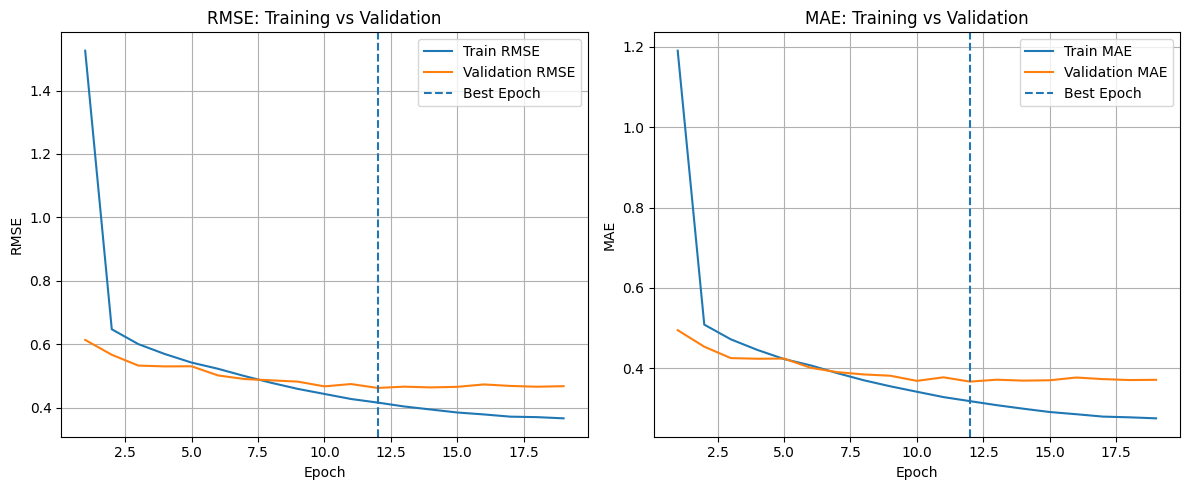

In [33]:
epochs = range(1, len(train_mae_list) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- RMSE plot ---
ax[0].plot(epochs, train_rmse_list, label="Train RMSE")
ax[0].plot(epochs, val_rmse_list, label="Validation RMSE")
ax[0].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[0].set_title("RMSE: Training vs Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[0].legend()
ax[0].grid()

# --- MAE plot ---
ax[1].plot(epochs, train_mae_list, label="Train MAE")
ax[1].plot(epochs, val_mae_list, label="Validation MAE")
ax[1].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[1].set_title("MAE: Training vs Validation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MAE")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.savefig(model_figs, dpi=300, bbox_inches="tight")
plt.show()

### Evaluation on test set

In [34]:
def collect_predictions(model, df, loader):
    model.eval()

    results = []

    total_time = 0
    total_samples = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating")

        for imgs, labels, idx in pbar:
            imgs = imgs.to(device)

            start = time.time()
            preds = model(imgs)
            end = time.time()

            batch_time = end - start

            total_time += batch_time
            total_samples += imgs.size(0)

            preds = preds.cpu().numpy()

            for i in range(len(preds)):
                row = df.iloc[idx[i].item()]

                results.append({
                    "pred": preds[i],
                    "true": labels[i].item(),
                    "gender": row["gender"],
                    "age": row["age"]
                })

    results_df = pd.DataFrame(results)

    # --- metrics ---
    mae = np.mean(np.abs(results_df["true"] - results_df["pred"]))
    rmse = np.sqrt(np.mean((results_df["true"] - results_df["pred"])**2))

    latency_per_batch = total_time / len(loader)
    latency_per_sample = total_time / total_samples

    return preds, results_df, mae, rmse, latency_per_batch, latency_per_sample

In [35]:
def compute_group_mae(df, group_col):
    group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))

    worst_group = group_mae.max()
    best_group = group_mae.min()
    gap = worst_group - best_group

    return group_mae, worst_group, gap

def compute_fairness_metrics(results_df):
    metrics = {}

    # ---- Gender ----
    gender_mae, gender_worst, gender_gap = compute_group_mae(results_df, "gender")

    metrics["gender"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in gender_mae.items()},
        "worst_group_mae": round(float(gender_worst), 5),
        "gap": round(float(gender_gap), 5)
    }

    # ---- Age ----
    results_df = results_df.copy()
    results_df["age_group"] = pd.cut(results_df["age"], bins=[13, 17, 20, 22, 26, 44])

    age_mae, age_worst, age_gap = compute_group_mae(results_df, "age_group")

    metrics["age"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in age_mae.items()},
        "worst_group_mae": round(float(age_worst), 5),
        "gap": round(float(age_gap), 5)
    }
    return metrics


def replace_nan(d, value=None):
    if isinstance(d, dict):
        return {
            k: replace_nan(v, value)
            for k, v in d.items()
        }
    if isinstance(d, float) and math.isnan(d):
        return value
    return d

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TemporalSensorGRU(input_dim=len(sensor_cols)).to(device)

model.load_state_dict(torch.load(model_path))
model.eval()

/scratch-local/cfragkiadakis.22708697/ipykernel_208185/2113614316.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


TemporalSensorGRU(
  (gru): GRU(15, 32, batch_first=True)
  (regressor): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [40]:
preds, results_df, best_mae, best_rmse, best_latency_batch, best_latency_sample = collect_predictions(model, test_df, test_loader)
fairness_metrics = compute_fairness_metrics(results_df)
results = {
    "mae": round(float(best_mae),4),
    "rmse": round(float(best_rmse),4),
    "latency_per_batch": round(float(best_latency_batch),4),
    "latency_per_sample_ms": round(float(best_latency_sample * 1000),4),
    "fairness": fairness_metrics
}

clean_results = replace_nan(results, value=None)

with open(model_results, "w") as f:
    json.dump(clean_results, f, indent=4)

Evaluating: 100%|██████████| 137/137 [00:01<00:00, 71.92it/s]
/scratch-local/cfragkiadakis.22708697/ipykernel_208185/832888187.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.22708697/ipykernel_208185/832888187.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.22708697

In [41]:
print('MAE:', results['mae'])

MAE: 0.3165


In [135]:
print("MAE per gender:\n", results['fairness']['gender']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['gender']['worst_group_mae']}")
print(f"Gap: {results['fairness']['gender']['gap']}")

MAE per gender:
 {'female': 0.33907, 'male': 0.32852}

Worst-group MAE: 0.33907
Gap: 0.01055


In [136]:
print("MAE per age:\n", results['fairness']['age']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['age']['worst_group_mae']}")
print(f"Gap: {results['fairness']['age']['gap']}")

MAE per age:
 {'(13, 17]': 0.35452, '(17, 20]': 0.32731, '(20, 22]': 0.38013, '(22, 26]': 0.30859, '(26, 44]': nan}

Worst-group MAE: 0.38013
Gap: 0.07155


In [42]:
mean_pred = train_df["attention"].mean()

baseline_mae = (
    test_df["attention"] - mean_pred
).abs().mean()

print(mean_pred)
print(baseline_mae)

2.929521203789658
0.3205320133546336


In [43]:
print(preds.min())
print(preds.max())
print(preds.mean())
print(preds.std())

2.832844
3.1737967
2.9868064
0.08857527
